In [16]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [17]:
df = pd.read_csv("../data/train_clear.csv")

In [18]:
# Использованы признаки, вошедшие в топ 10 по важности у логистической регрессии
# Использование большого количества признаков снижает точность до 0.64 из-за проклятия размерности (расстояние становится)

important_features = [
    "ALT",
    "AST",
    "Bilirubin",
    "Sym_Jaundice",
    "Platelets",
    "Comorb_Diabetes",
    "Sym_Dark_Urine",
    "Sym_Fatigue",
    "Albumin",
    "Sym_Itching"
]

In [19]:
target = "Liver_Disease_Type"
X = df[important_features]
y = df[target]

In [20]:
X_encoded = X.copy()

In [21]:
# Масштабирование критически важно, так как нормализует расстояние

X_scaled = StandardScaler().fit_transform(X_encoded)

In [22]:
le = LabelEncoder()
y_encoded = np.array(le.fit_transform(y))

In [23]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

In [24]:
all_y_true = []
all_y_pred = []

In [25]:
for fold, (train_index, val_index) in enumerate(skf.split(X_scaled, y_encoded)):
    X_train, X_val = X_scaled[train_index], X_scaled[val_index]
    y_train, y_val = y_encoded[train_index], y_encoded[val_index]
    
    model = KNeighborsClassifier()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    
    score = model.score(X_val, y_val)
    cv_scores.append(score)

    all_y_true.extend(y_val)
    all_y_pred.extend(y_pred)

In [26]:
scores = np.array(cv_scores)

In [27]:
f"Точность KNN: {scores.mean():0.3f} ± {scores.std():0.3f}"

'Точность KNN: 0.790 ± 0.004'

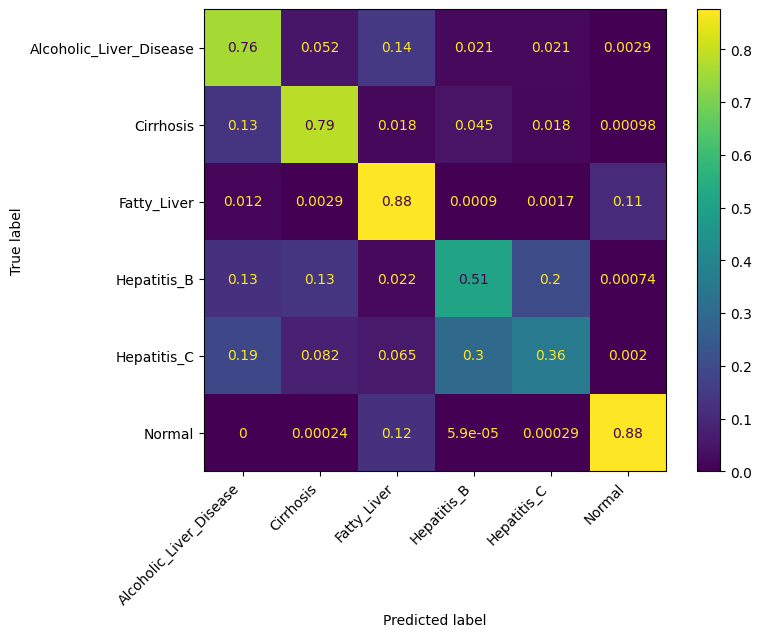

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
disp_raw = ConfusionMatrixDisplay.from_predictions(
    all_y_true, 
    all_y_pred, 
    display_labels=le.classes_,
    ax=ax,
    normalize="true"
)
plt.xticks(rotation=45, ha='right')
plt.show()